# 03 – PCA: Giảm Chiều Dữ Liệu
**Pipeline stage:** Data Processing → PCA – Giảm chiều → Econometric Modeling

Mục tiêu notebook này:
- Áp dụng **Principal Component Analysis (PCA)** lên nhóm biến độc lập liên tục (log-transformed)
- Xác định số PC tối ưu theo tiêu chí **Kaiser (eigenvalue > 1)**, **Scree plot**, và **ngưỡng phương sai tích lũy**
- Diễn giải ý nghĩa kinh tế của từng PC thông qua **loading matrix**
- Tạo **PC scores** làm input thay thế cho các bước: LASSO, PPML, Machine Learning

> ⚠️ **Lưu ý:** PCA ở đây áp dụng cho **biến độc lập** (covariates), không phải biến phụ thuộc `ln_migration`.
> Biến phụ thuộc vẫn giữ nguyên trong tất cả các mô hình.

## 0. Import thư viện & Cấu hình

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('../output/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Style chung ──
plt.rcParams.update({
    'font.family'    : 'DejaVu Sans',
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'figure.dpi'     : 120,
})

SEED = 42
np.random.seed(SEED)
print('✅ Import hoàn tất')

✅ Import hoàn tất


## 1. Load dữ liệu đã xử lý

In [19]:
df = pd.read_csv('../data/processed/data_clean.csv', low_memory=False)
df_ppml = pd.read_csv('../data/processed/data_ppml.csv', low_memory=False)

print(f'data_clean : {df.shape}')
print(f'data_ppml  : {df_ppml.shape}')
df.head(3)

data_clean : (9125, 74)
data_ppml  : (16250, 73)


,iso_o,iso_d,pair_id,year,iso_o_year,iso_d_year,migration,gdp_org,gdp_des,gdppc_org,gdppc_des,inflation_org,inflation_des,dist,distcap,distwces,comlang_off,contig,colony,pop_org,pop_des,disaster_org,disaster_des,co2_org,co2_des,pm25_exceed_org,pm25_exceed_des,pm25_org,pm25_des,internet_use_org,internet_use_des,internet_indiv_org,internet_indiv_des,bandwidth_org,bandwidth_des,ln_gdp_org,ln_gdp_des,ln_gdppc_org,ln_gdppc_des,ln_pop_org,ln_pop_des,ln_dist,ln_co2_org,ln_pm25_org,ln_migration,ln_internet_use_org,ln_bandwidth_org,ln_disaster_org,ln_disaster_des,yr_2001,yr_2002,yr_2003,yr_2004,yr_2005,yr_2006,yr_2007,yr_2008,yr_2009,yr_2010,yr_2011,yr_2012,yr_2013,yr_2014,yr_2015,yr_2016,yr_2017,yr_2018,yr_2019,yr_2020,yr_2021,yr_2022,yr_2023,yr_2024,ln_gdppc_x_internet
0,AUS,CAN,AUS_CAN,2000,AUS2000,CAN2000,15831.0000,416167815092.9080,744773415931.5870,26541.6660,29362.0840,4.4574,2.7194,15586.6600,16123.0000,15223.9900,1,0,0,19028802,30685730,4,1,18.5965,17.6970,33.8321,11.0213,7.4574,9.7957,46.7561,51.3000,0.467561,0.513,274.3810,2200.2400,26.7544,27.3363,10.1865,10.2875,16.7615,17.2393,9.6542,2.9230,2.0092,9.6697,3.8661,5.6182,1.6094,0.6931,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,39.3820
1,AUS,CAN,AUS_CAN,2001,AUS2001,CAN2001,16223.0000,379629301675.1080,738981792355.3719,27645.8145,30230.8496,4.4071,2.5251,15586.6600,16123.0000,15223.9900,1,0,0,19274701,31020855,7,1,18.6985,17.2242,0.0000,0.0000,7.3890,9.7609,52.6893,60.2000,0.526893,0.602,688.4790,2960.1499,26.6625,27.3285,10.2272,10.3166,16.7743,17.2502,9.6542,2.9284,2.0000,9.6942,3.9832,6.5359,2.0794,0.6931,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,40.7372
2,AUS,CAN,AUS_CAN,2002,AUS2002,CAN2002,16626.0000,395788696012.0590,760649334098.0050,29032.4902,30963.9219,2.9816,2.2584,15586.6600,16123.0000,15223.9900,1,0,0,19495210,31359199,3,1,18.9083,17.6673,0.0000,0.0000,7.2663,9.7281,0.0000,61.5933,0,0.615933,0.0000,4596.0600,26.7041,27.3574,10.2762,10.3406,16.7857,17.2610,9.6542,2.9396,1.9833,9.7187,0.0000,0.0000,1.3863,0.6931,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.0000


## 2. Xác định nhóm biến đưa vào PCA

PCA áp dụng trên **log-transformed continuous covariates** – chia 3 nhóm:

| Nhóm | Ý nghĩa | Biến |
|------|---------|------|
| **Origin** | Đặc trưng kinh tế-xã hội-môi trường nước gốc | GDP, GDPpc, Pop, CO2, PM2.5, Internet, Bandwidth, Disaster |
| **Destination** | Đặc trưng nước đến | GDP, GDPpc, Pop, Disaster |
| **Bilateral** | Đặc trưng cặp quốc gia | Khoảng cách, ngôn ngữ, biên giới, thuộc địa |

> **Không đưa vào PCA:** biến phụ thuộc `ln_migration`, dummies năm (`yr_*`), inflation (có giá trị âm hợp lệ – giảm phát).

In [3]:
# ── Nhóm biến ──
ORG_FEATURES = [
    'ln_gdp_org', 'ln_gdppc_org', 'ln_pop_org',
    'ln_co2_org', 'ln_pm25_org',
    'ln_internet_use_org', 'ln_bandwidth_org', 'ln_disaster_org'
]

DES_FEATURES = [
    'ln_gdp_des', 'ln_gdppc_des', 'ln_pop_des', 'ln_disaster_des'
]

BILATERAL_FEATURES = [
    'ln_dist', 'comlang_off', 'contig', 'colony'
]

ALL_FEATURES = ORG_FEATURES + DES_FEATURES + BILATERAL_FEATURES

print(f'Nhóm Origin      : {len(ORG_FEATURES)} biến → {ORG_FEATURES}')
print(f'Nhóm Destination : {len(DES_FEATURES)} biến → {DES_FEATURES}')
print(f'Nhóm Bilateral   : {len(BILATERAL_FEATURES)} biến → {BILATERAL_FEATURES}')
print(f'Tổng số biến PCA : {len(ALL_FEATURES)}')

Nhóm Origin      : 8 biến → ['ln_gdp_org', 'ln_gdppc_org', 'ln_pop_org', 'ln_co2_org', 'ln_pm25_org', 'ln_internet_use_org', 'ln_bandwidth_org', 'ln_disaster_org']
Nhóm Destination : 4 biến → ['ln_gdp_des', 'ln_gdppc_des', 'ln_pop_des', 'ln_disaster_des']
Nhóm Bilateral   : 4 biến → ['ln_dist', 'comlang_off', 'contig', 'colony']
Tổng số biến PCA : 16


In [4]:
# ── Chuẩn bị ma trận X ──
X_raw = df[ALL_FEATURES].apply(pd.to_numeric, errors='coerce')
valid_idx = X_raw.dropna().index
X_raw = X_raw.loc[valid_idx]
df_pca_work = df.loc[valid_idx].copy()

print(f'Số quan sát hợp lệ cho PCA: {len(X_raw):,} / {len(df):,}')
print(f'Missing loại bỏ           : {len(df) - len(X_raw):,}')
print()

# Standardize (zero mean, unit variance) – bắt buộc với PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print('Sau StandardScaler:')
print(f'  Mean ≈ {X_scaled.mean():.6f}  (kỳ vọng ≈ 0)')
print(f'  Std  ≈ {X_scaled.std():.6f}   (kỳ vọng ≈ 1)')

Số quan sát hợp lệ cho PCA: 9,125 / 9,125
Missing loại bỏ           : 0

Sau StandardScaler:
  Mean ≈ 0.000000  (kỳ vọng ≈ 0)
  Std  ≈ 1.000000   (kỳ vọng ≈ 1)


## 3. Chạy PCA toàn phần & Xác định số thành phần tối ưu

Ba tiêu chí lựa chọn số PC:
1. **Kaiser criterion**: giữ PC có eigenvalue > 1
2. **Scree plot**: tìm điểm 'khuỷu tay' (elbow)
3. **Ngưỡng phương sai tích lũy**: ≥ 80%, 85%, 90%

In [5]:
# ── Chạy PCA toàn phần ──
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

evr        = pca_full.explained_variance_ratio_
eigenvals  = pca_full.explained_variance_
cum_evr    = np.cumsum(evr)
n_features = len(ALL_FEATURES)

# ── Bảng tóm tắt ──
summary = pd.DataFrame({
    'PC'              : [f'PC{i+1}' for i in range(n_features)],
    'Eigenvalue'      : eigenvals.round(4),
    'Var Explained'   : evr.round(4),
    'Cumulative Var'  : cum_evr.round(4),
})
summary['Kaiser (>1)'] = summary['Eigenvalue'] > 1
print(summary.to_string(index=False))

  PC  Eigenvalue  Var Explained  Cumulative Var  Kaiser (>1)
 PC1      2.5669         0.1604          0.1604         True
 PC2      2.4709         0.1544          0.3148         True
 PC3      2.4042         0.1502          0.4651         True
 PC4      1.9249         0.1203          0.5854         True
 PC5      1.5905         0.0994          0.6848         True
 PC6      1.1649         0.0728          0.7576         True
 PC7      0.9451         0.0591          0.8166        False
 PC8      0.7671         0.0479          0.8646        False
 PC9      0.6363         0.0398          0.9043        False
PC10      0.5242         0.0328          0.9371        False
PC11      0.3940         0.0246          0.9617        False
PC12      0.2327         0.0145          0.9763        False
PC13      0.1923         0.0120          0.9883        False
PC14      0.1715         0.0107          0.9990        False
PC15      0.0096         0.0006          0.9996        False
PC16      0.0064        

In [6]:
# ── Xác định n_components theo từng tiêu chí ──
kaiser_n   = int((eigenvals > 1).sum())
n_80       = int(np.argmax(cum_evr >= 0.80) + 1)
n_85       = int(np.argmax(cum_evr >= 0.85) + 1)
n_90       = int(np.argmax(cum_evr >= 0.90) + 1)

print('=' * 50)
print(f'Tiêu chí Kaiser (eigenvalue > 1) : {kaiser_n} PCs')
print(f'Ngưỡng 80% phương sai tích lũy   : {n_80} PCs')
print(f'Ngưỡng 85% phương sai tích lũy   : {n_85} PCs')
print(f'Ngưỡng 90% phương sai tích lũy   : {n_90} PCs')
print('=' * 50)
print(f'→ Chọn N_COMPONENTS = {kaiser_n} (theo Kaiser – cân bằng giữa parsimony và information)')

N_COMPONENTS = kaiser_n

Tiêu chí Kaiser (eigenvalue > 1) : 6 PCs
Ngưỡng 80% phương sai tích lũy   : 7 PCs
Ngưỡng 85% phương sai tích lũy   : 8 PCs
Ngưỡng 90% phương sai tích lũy   : 9 PCs
→ Chọn N_COMPONENTS = 6 (theo Kaiser – cân bằng giữa parsimony và information)


## 4. Scree Plot & Cumulative Variance Plot

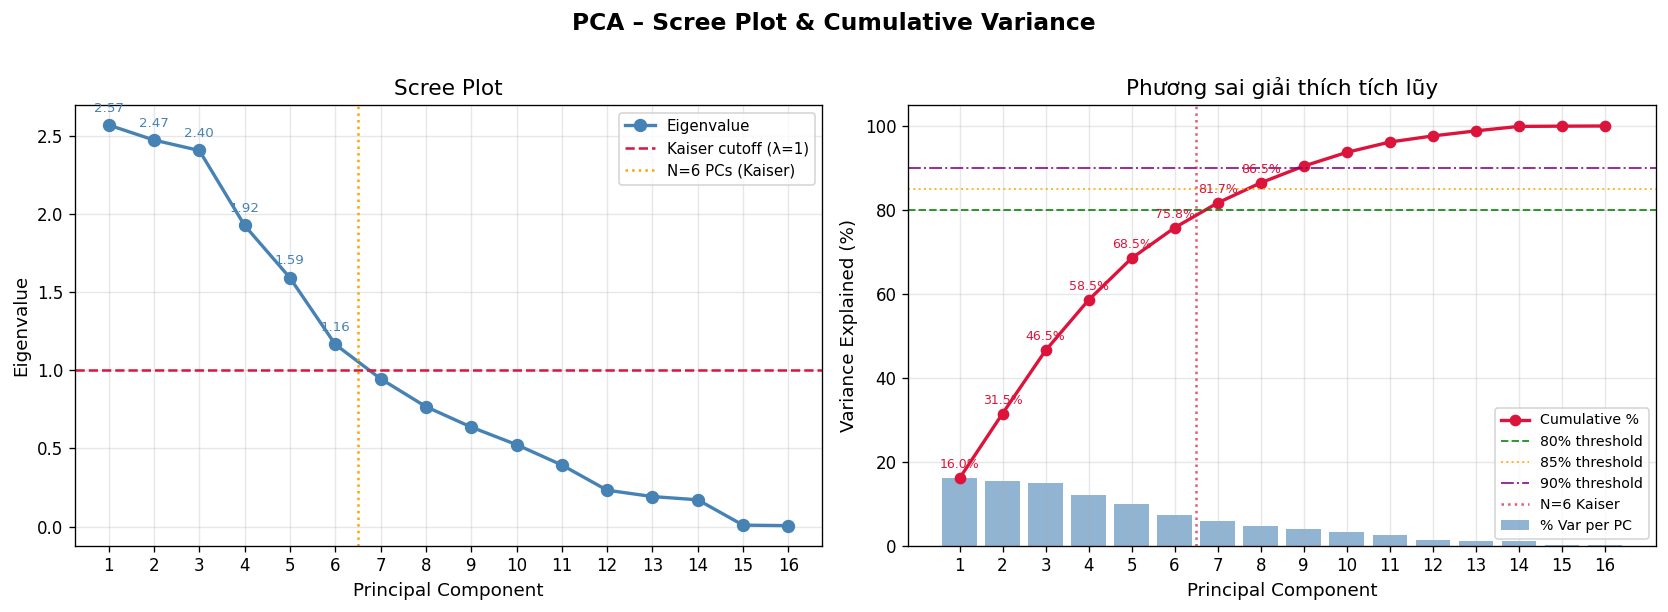

→ Saved: output/figures/pca_scree_variance.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pcs = np.arange(1, n_features + 1)

# ── Scree plot ──
ax = axes[0]
ax.plot(pcs, eigenvals, 'o-', color='steelblue', linewidth=2, markersize=7, label='Eigenvalue')
ax.axhline(y=1, color='crimson', linestyle='--', linewidth=1.5, label='Kaiser cutoff (λ=1)')
ax.axvline(x=N_COMPONENTS + 0.5, color='orange', linestyle=':', linewidth=1.5,
           label=f'N={N_COMPONENTS} PCs (Kaiser)')
for i, val in enumerate(eigenvals[:N_COMPONENTS]):
    ax.annotate(f'{val:.2f}', (i+1, val), textcoords='offset points',
               xytext=(0, 8), ha='center', fontsize=8, color='steelblue')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Eigenvalue')
ax.set_title('Scree Plot')
ax.set_xticks(pcs)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Cumulative variance ──
ax2 = axes[1]
bars = ax2.bar(pcs, evr * 100, color='steelblue', alpha=0.6, label='% Var per PC')
line = ax2.plot(pcs, cum_evr * 100, 'o-', color='crimson', linewidth=2,
                markersize=6, label='Cumulative %')
for thresh, ls, col in [(80,'--','green'),(85,':','orange'),(90,'-.','purple')]:
    ax2.axhline(y=thresh, color=col, linestyle=ls, linewidth=1.2, alpha=0.8,
                label=f'{thresh}% threshold')
ax2.axvline(x=N_COMPONENTS + 0.5, color='crimson', linestyle=':', linewidth=1.5,
            alpha=0.7, label=f'N={N_COMPONENTS} Kaiser')
# Annotate cumulative values
for i, c in enumerate(cum_evr[:N_COMPONENTS+2]):
    ax2.annotate(f'{c*100:.1f}%', (i+1, c*100), textcoords='offset points',
                 xytext=(0, 6), ha='center', fontsize=7.5, color='crimson')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('Phương sai giải thích tích lũy')
ax2.set_xticks(pcs)
ax2.legend(fontsize=8.5, loc='lower right')
ax2.grid(True, alpha=0.3)

plt.suptitle('PCA – Scree Plot & Cumulative Variance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/figures/pca_scree_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'→ Saved: output/figures/pca_scree_variance.png')

## 5. Loading Matrix – Diễn giải PC

Loading matrix cho biết **mỗi biến gốc đóng góp bao nhiêu** vào từng PC.
Loading cao (|loading| > 0.3) → biến đó 'đặc trưng' cho PC đó.

In [8]:
# ── Loading matrix ──
loadings = pd.DataFrame(
    pca_full.components_[:N_COMPONENTS, :].T,
    index   = ALL_FEATURES,
    columns = [f'PC{i+1}' for i in range(N_COMPONENTS)]
)

print('Loading Matrix (chỉ hiển thị PC1–PC{N_COMPONENTS}):')
print(loadings.round(3).to_string())

Loading Matrix (chỉ hiển thị PC1–PC{N_COMPONENTS}):
                        PC1     PC2     PC3     PC4     PC5     PC6
ln_gdp_org          -0.4070  0.4260  0.0840  0.0480  0.1250 -0.0800
ln_gdppc_org        -0.3200  0.1040  0.4730  0.0300 -0.0110 -0.2420
ln_pop_org          -0.1840  0.4290 -0.3510 -0.0420  0.1800  0.1280
ln_co2_org          -0.1280  0.0420  0.0100  0.5290 -0.2030  0.0800
ln_pm25_org          0.0330 -0.0600 -0.2630  0.4650 -0.1640  0.1790
ln_internet_use_org -0.3200  0.1340  0.3990  0.2240 -0.1180 -0.1280
ln_bandwidth_org    -0.0250 -0.0280 -0.0510  0.4910 -0.1870  0.2160
ln_disaster_org     -0.1810  0.4250 -0.3290 -0.0520  0.2020  0.1150
ln_gdp_des           0.3260  0.2790  0.3380 -0.0450 -0.1000  0.3270
ln_gdppc_des        -0.1490 -0.0100  0.2370 -0.3290 -0.2800  0.5350
ln_pop_des           0.4480  0.3160  0.1820  0.1600  0.1520 -0.1250
ln_disaster_des      0.4390  0.3060  0.1710  0.1430  0.1210 -0.1180
ln_dist              0.1050  0.3230 -0.1310 -0.1330 -0.3860  0.0

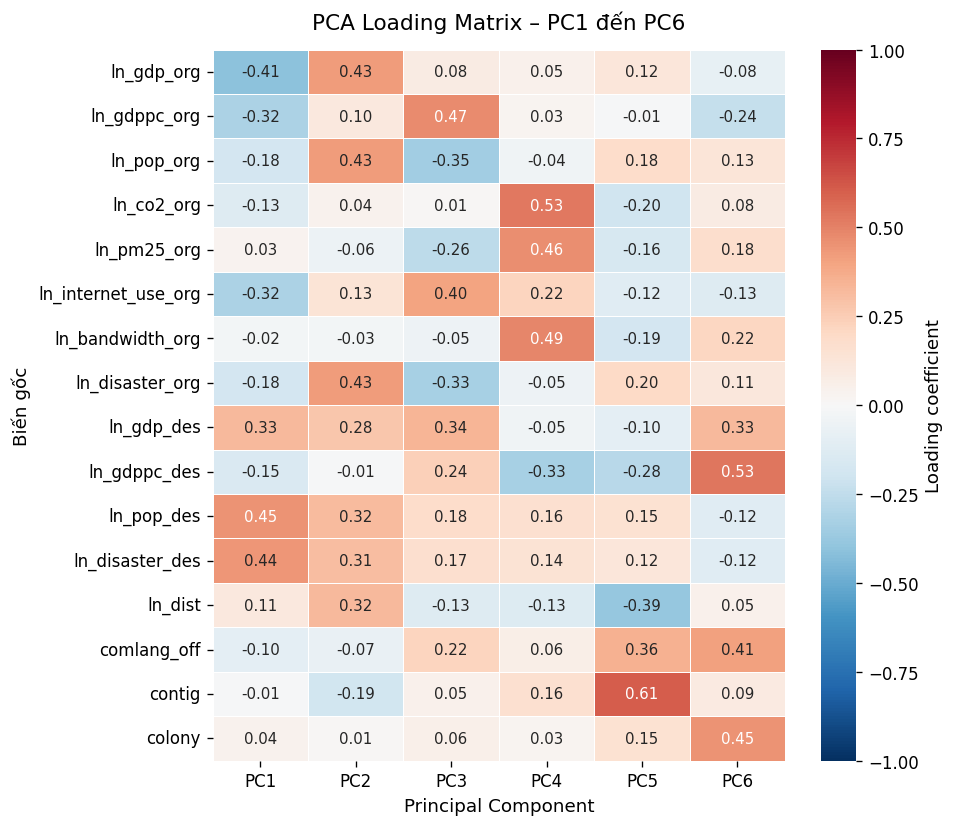

→ Saved: output/figures/pca_loading_heatmap.png


In [9]:
# ── Heatmap loading matrix ──
fig, ax = plt.subplots(figsize=(max(8, N_COMPONENTS*1.2), 7))

sns.heatmap(
    loadings,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'RdBu_r',
    center     = 0,
    vmin       = -1, vmax = 1,
    linewidths = 0.4,
    ax         = ax,
    annot_kws  = {'size': 9},
    cbar_kws   = {'label': 'Loading coefficient'}
)
ax.set_title(f'PCA Loading Matrix – PC1 đến PC{N_COMPONENTS}', fontsize=13, pad=12)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Biến gốc')
plt.tight_layout()
plt.savefig('../output/figures/pca_loading_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Saved: output/figures/pca_loading_heatmap.png')

In [10]:
# ── Diễn giải kinh tế từng PC ──
print('=' * 65)
print('DIỄN GIẢI Ý NGHĨA KINH TẾ TỪNG PRINCIPAL COMPONENT')
print('=' * 65)

for pc_idx in range(N_COMPONENTS):
    pc_name   = f'PC{pc_idx+1}'
    pc_load   = loadings[pc_name].abs().sort_values(ascending=False)
    top3      = pc_load.head(3)
    var_pct   = evr[pc_idx] * 100
    cum_pct   = cum_evr[pc_idx] * 100
    eigenval  = eigenvals[pc_idx]
    sign_vars = loadings[pc_name][loadings[pc_name].abs() > 0.30]
    pos_vars  = sign_vars[sign_vars > 0].index.tolist()
    neg_vars  = sign_vars[sign_vars < 0].index.tolist()

    print(f'\n{pc_name} | λ={eigenval:.3f} | Var={var_pct:.1f}% | Cum={cum_pct:.1f}%')
    print(f'  Top loadings (|load|>0.30):')
    for var in pc_load[pc_load > 0.30].index:
        print(f'    (+) {var:<30s}: {loadings[pc_name][var]:+.3f}')
    for var in loadings[pc_name][loadings[pc_name] < -0.30].index:
        print(f'    (-) {var:<30s}: {loadings[pc_name][var]:+.3f}')

DIỄN GIẢI Ý NGHĨA KINH TẾ TỪNG PRINCIPAL COMPONENT

PC1 | λ=2.567 | Var=16.0% | Cum=16.0%
  Top loadings (|load|>0.30):
    (+) ln_pop_des                    : +0.448
    (+) ln_disaster_des               : +0.439
    (+) ln_gdp_org                    : -0.407
    (+) ln_gdp_des                    : +0.326
    (+) ln_gdppc_org                  : -0.320
    (+) ln_internet_use_org           : -0.320
    (-) ln_gdp_org                    : -0.407
    (-) ln_gdppc_org                  : -0.320
    (-) ln_internet_use_org           : -0.320

PC2 | λ=2.471 | Var=15.4% | Cum=31.5%
  Top loadings (|load|>0.30):
    (+) ln_pop_org                    : +0.429
    (+) ln_gdp_org                    : +0.426
    (+) ln_disaster_org               : +0.425
    (+) ln_dist                       : +0.323
    (+) ln_pop_des                    : +0.316
    (+) ln_disaster_des               : +0.306

PC3 | λ=2.404 | Var=15.0% | Cum=46.5%
  Top loadings (|load|>0.30):
    (+) ln_gdppc_org                 

## 6. Biplot PC1 vs PC2

Biplot kết hợp hiển thị **PC scores** (điểm mẫu) và **loading vectors** (hướng biến gốc).
Các biến gốc gần nhau → tương quan dương; ngược hướng → tương quan âm.

In [11]:
# ── Tính PC scores ──
pca_selected = PCA(n_components=N_COMPONENTS, random_state=SEED)
PC_scores = pca_selected.fit_transform(X_scaled)
PC_scores_df = pd.DataFrame(
    PC_scores,
    index   = X_raw.index,
    columns = [f'PC{i+1}' for i in range(N_COMPONENTS)]
)
print(f'PC scores shape: {PC_scores_df.shape}')
print(PC_scores_df.head(3))

PC scores shape: (9125, 6)
      PC1     PC2     PC3     PC4    PC5    PC6
0 -0.2966  0.1892  0.6847  0.2335 0.3468 1.2753
1 -0.4153  0.3829  0.5772  0.3234 0.3768 1.3749
2  0.7400 -0.2688 -0.3454 -1.1070 0.8918 1.3805


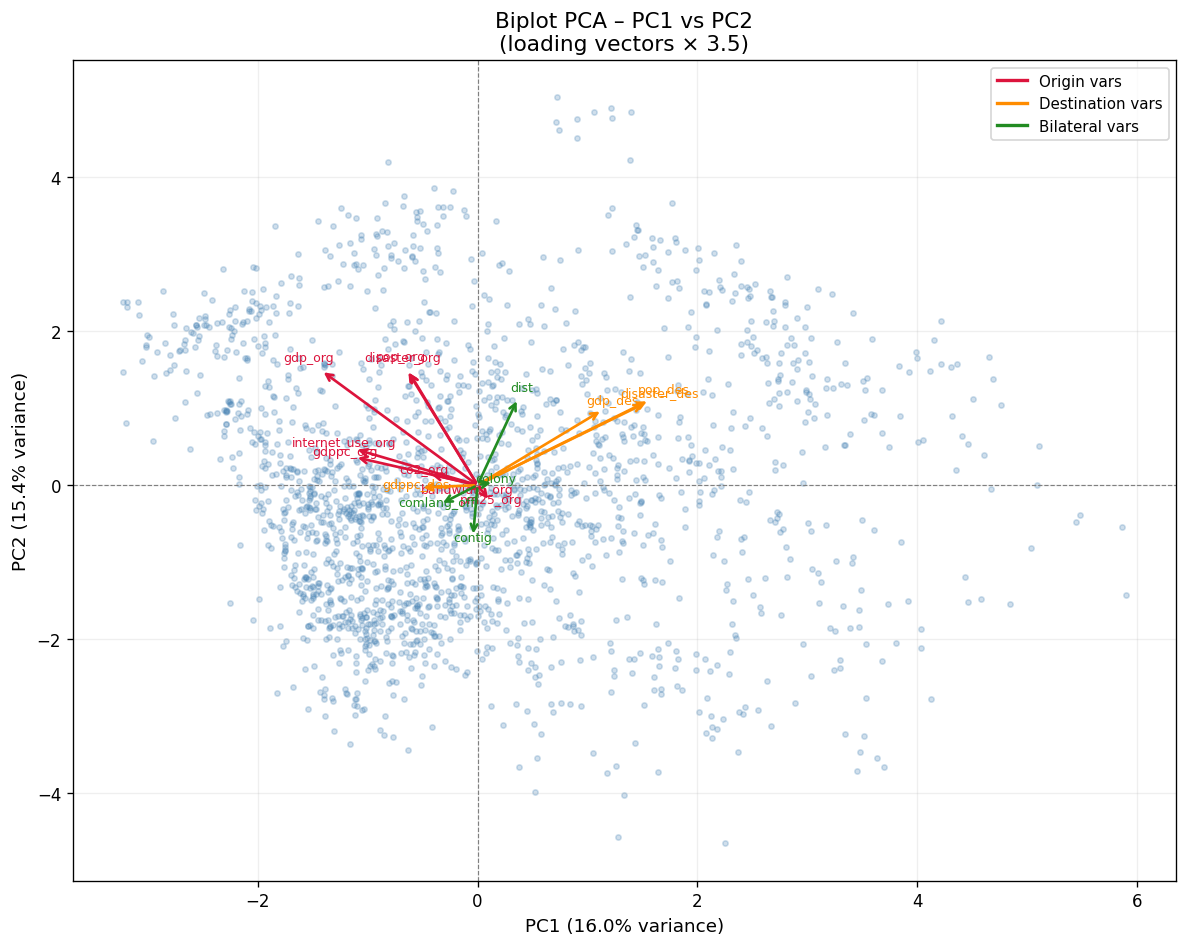

→ Saved: output/figures/pca_biplot_pc1_pc2.png


In [12]:
# ── Biplot PC1 vs PC2 ──
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter scores (subsample để tránh overplot)
sample_idx = np.random.choice(len(PC_scores_df), size=min(2000, len(PC_scores_df)), replace=False)
ax.scatter(PC_scores_df['PC1'].iloc[sample_idx],
           PC_scores_df['PC2'].iloc[sample_idx],
           alpha=0.25, s=10, color='steelblue', label='Quan sát')

# Loading vectors
scale = 3.5  # scale factor để loading vectors dễ thấy
loadings_2pc = pd.DataFrame(
    pca_selected.components_[:2, :].T,
    index=ALL_FEATURES, columns=['PC1','PC2']
)

# Màu theo nhóm biến
colors_map = {}
for v in ORG_FEATURES:      colors_map[v] = 'crimson'
for v in DES_FEATURES:      colors_map[v] = 'darkorange'
for v in BILATERAL_FEATURES: colors_map[v] = 'forestgreen'

for var in ALL_FEATURES:
    x_end = loadings_2pc.loc[var, 'PC1'] * scale
    y_end = loadings_2pc.loc[var, 'PC2'] * scale
    ax.annotate('', xy=(x_end, y_end), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors_map[var], lw=1.6))
    ax.text(x_end * 1.08, y_end * 1.08, var.replace('ln_', ''),
            fontsize=7.5, ha='center', color=colors_map[var])

# Legend nhóm
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='crimson',     lw=2, label='Origin vars'),
    Line2D([0],[0], color='darkorange',  lw=2, label='Destination vars'),
    Line2D([0],[0], color='forestgreen', lw=2, label='Bilateral vars'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
ax.set_title('Biplot PCA – PC1 vs PC2\n(loading vectors × 3.5)', fontsize=13)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../output/figures/pca_biplot_pc1_pc2.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Saved: output/figures/pca_biplot_pc1_pc2.png')

## 7. Phân phối PC Scores

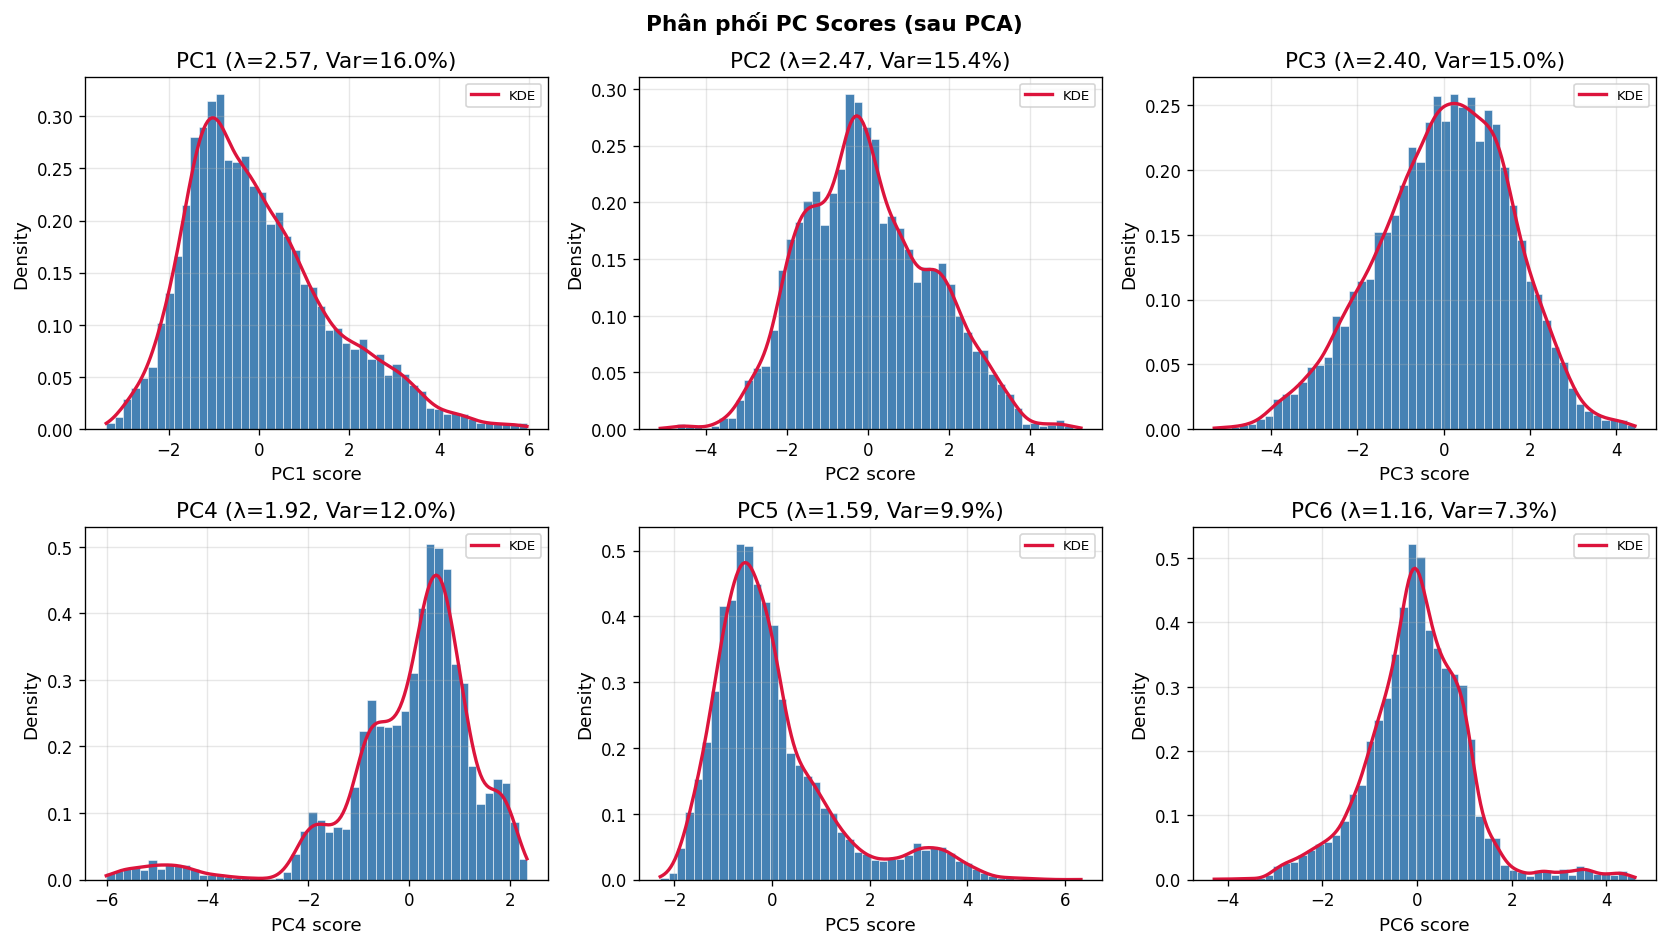

→ Saved: output/figures/pca_score_distributions.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i in range(N_COMPONENTS):
    ax = axes[i]
    scores = PC_scores_df[f'PC{i+1}']
    ax.hist(scores, bins=50, color='steelblue', edgecolor='white', linewidth=0.3, density=True)

    # KDE overlay
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(scores.dropna())
    x_range = np.linspace(scores.min(), scores.max(), 200)
    ax.plot(x_range, kde(x_range), color='crimson', linewidth=2, label='KDE')

    ax.set_title(f'PC{i+1} (λ={eigenvals[i]:.2f}, Var={evr[i]*100:.1f}%)')
    ax.set_xlabel(f'PC{i+1} score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Ẩn subplot thừa nếu N_COMPONENTS < 6
for j in range(N_COMPONENTS, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân phối PC Scores (sau PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/pca_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Saved: output/figures/pca_score_distributions.png')

## 8. Tương quan PC Scores với `ln_migration`

Kiểm tra PC nào có tương quan mạnh nhất với biến phụ thuộc → định hướng mô hình.

Tương quan Pearson giữa PC scores và ln_migration:
PC1   0.0569
PC2   0.2934
PC3   0.1288
PC4   0.0267
PC5   0.2373
PC6   0.3000


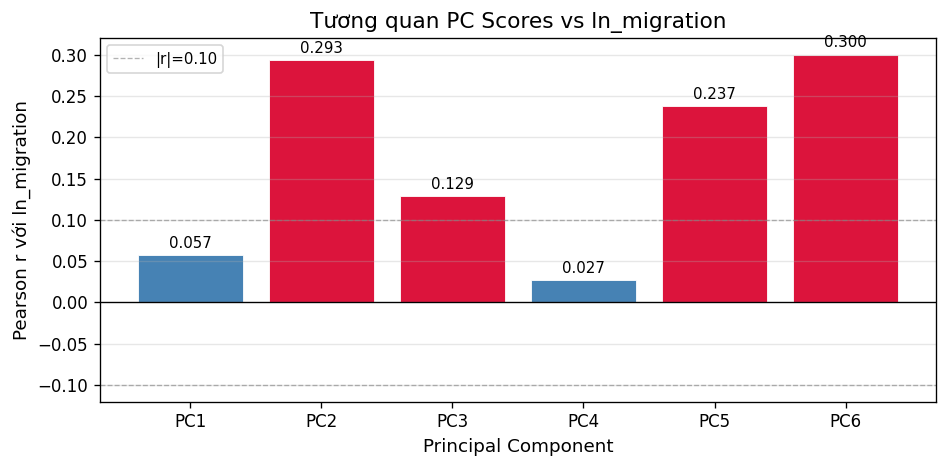

→ Saved: output/figures/pca_correlation_with_target.png


In [14]:
# Ghép PC scores với df_pca_work
df_with_pcs = df_pca_work.copy()
for col in PC_scores_df.columns:
    df_with_pcs[col] = PC_scores_df[col].values

# Tương quan Pearson
pc_cols = [f'PC{i+1}' for i in range(N_COMPONENTS)]
corr_with_target = df_with_pcs[pc_cols + ['ln_migration']].corr()['ln_migration'].drop('ln_migration')

print('Tương quan Pearson giữa PC scores và ln_migration:')
print(corr_with_target.round(4).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['crimson' if abs(c) > 0.1 else 'steelblue' for c in corr_with_target]
bars = ax.bar(pc_cols, corr_with_target.values, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.1, color='gray', linewidth=0.8, linestyle='--', alpha=0.6, label='|r|=0.10')
ax.axhline(-0.1, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
for bar, val in zip(bars, corr_with_target.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.005 if val >= 0 else -0.012),
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Pearson r với ln_migration')
ax.set_title('Tương quan PC Scores vs ln_migration')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../output/figures/pca_correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Saved: output/figures/pca_correlation_with_target.png')

## 9. Phân tích độ nhạy – Số PC vs R² (hồi quy OLS)

Chạy OLS đơn giản `ln_migration ~ PC1 + ... + PCk` với k từ 1 đến N_COMPONENTS.
Mục tiêu: xem thêm PC có cải thiện đáng kể R² không.

  k=1 PCs → R² = 0.0032
  k=2 PCs → R² = 0.0893
  k=3 PCs → R² = 0.1059
  k=4 PCs → R² = 0.1066
  k=5 PCs → R² = 0.1630
  k=6 PCs → R² = 0.2530


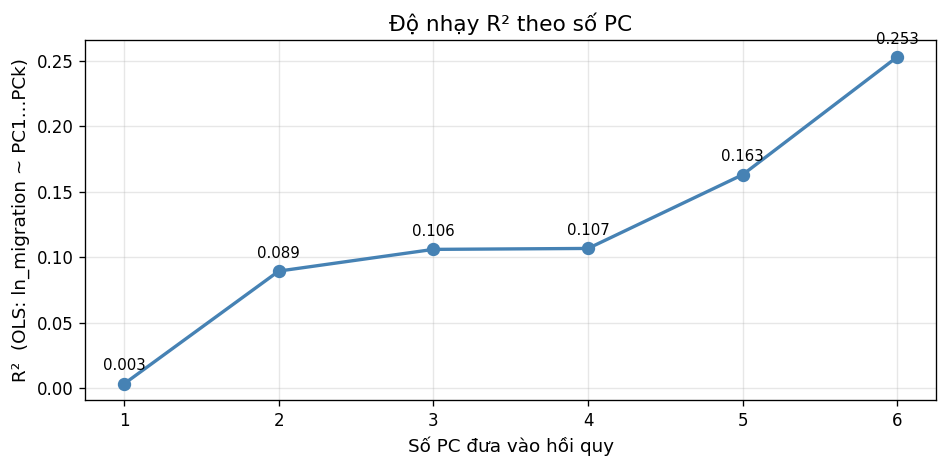

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Dữ liệu với target
target_col = 'ln_migration'
df_reg = df_with_pcs[pc_cols + [target_col]].dropna()
y = df_reg[target_col].values

r2_scores = []
for k in range(1, N_COMPONENTS + 1):
    X_k = df_reg[[f'PC{i+1}' for i in range(k)]].values
    reg = LinearRegression().fit(X_k, y)
    r2_k = r2_score(y, reg.predict(X_k))
    r2_scores.append(r2_k)
    print(f'  k={k} PCs → R² = {r2_k:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_COMPONENTS+1), r2_scores, 'o-', color='steelblue', linewidth=2, markersize=7)
for x, y_val in zip(range(1, N_COMPONENTS+1), r2_scores):
    ax.annotate(f'{y_val:.3f}', (x, y_val), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)
ax.set_xlabel('Số PC đưa vào hồi quy')
ax.set_ylabel('R²  (OLS: ln_migration ~ PC1...PCk)')
ax.set_title('Độ nhạy R² theo số PC')
ax.set_xticks(range(1, N_COMPONENTS+1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/figures/pca_r2_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Tái cấu trúc & Lưu dữ liệu

Thêm PC scores vào cả `data_clean.csv` và `data_ppml.csv` để dùng ở các bước tiếp theo.

In [16]:
# ── Pipeline đầy đủ: scaler + PCA ──
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=N_COMPONENTS, random_state=SEED))
])

def add_pc_scores(dataframe, features, pipeline, fit=False):
    """Thêm PC scores vào dataframe."""
    df_out = dataframe.copy()
    X = df_out[features].apply(pd.to_numeric, errors='coerce')
    valid_mask = X.notna().all(axis=1)

    if fit:
        scores = pipeline.fit_transform(X[valid_mask])
    else:
        scores = pipeline.transform(X[valid_mask])

    pc_names = [f'PC{i+1}' for i in range(N_COMPONENTS)]
    for i, name in enumerate(pc_names):
        df_out[name] = np.nan
        df_out.loc[valid_mask, name] = scores[:, i]
    return df_out

# Fit trên data_clean → transform cả hai
df_with_pcs_final  = add_pc_scores(df,      ALL_FEATURES, pca_pipeline, fit=True)
df_ppml_with_pcs   = add_pc_scores(df_ppml, ALL_FEATURES, pca_pipeline, fit=False)

pc_cols_added = [f'PC{i+1}' for i in range(N_COMPONENTS)]
print('PC scores đã thêm vào cả hai dataframe:')
print(f'  data_clean : {df_with_pcs_final.shape}')
print(f'  data_ppml  : {df_ppml_with_pcs.shape}')
print()
print('Thống kê PC scores (data_clean):')
print(df_with_pcs_final[pc_cols_added].describe().T[['mean','std','min','max']].round(4).to_string())

PC scores đã thêm vào cả hai dataframe:
  data_clean : (9125, 80)
  data_ppml  : (16250, 79)

Thống kê PC scores (data_clean):
       mean    std     min    max
PC1  0.0000 1.6022 -3.3890 5.9499
PC2 -0.0000 1.5719 -5.1246 5.2716
PC3  0.0000 1.5506 -5.3209 4.4363
PC4  0.0000 1.3874 -6.0078 2.3359
PC5 -0.0000 1.2612 -2.2920 6.3291
PC6 -0.0000 1.0793 -4.2804 4.6060


In [17]:
# ── Lưu ──
df_with_pcs_final.to_csv('../data/processed/data_clean_pca.csv', index=False)
df_ppml_with_pcs.to_csv('../data/processed/data_ppml_pca.csv', index=False)

# Lưu loading matrix để tham chiếu sau này
full_loadings = pd.DataFrame(
    pca_full.components_[:N_COMPONENTS, :].T,
    index   = ALL_FEATURES,
    columns = [f'PC{i+1}' for i in range(N_COMPONENTS)]
)
full_loadings.to_csv('../data/processed/pca_loadings.csv')

# Lưu explained variance summary
summary_out = pd.DataFrame({
    'PC'             : [f'PC{i+1}' for i in range(N_COMPONENTS)],
    'Eigenvalue'     : eigenvals[:N_COMPONENTS].round(4),
    'Var_Explained'  : evr[:N_COMPONENTS].round(4),
    'Cumulative_Var' : cum_evr[:N_COMPONENTS].round(4),
})
summary_out.to_csv('../data/processed/pca_variance_summary.csv', index=False)

print('✅ Đã lưu:')
print('   data/processed/data_clean_pca.csv     – data_clean + PC scores')
print('   data/processed/data_ppml_pca.csv      – data_ppml  + PC scores')
print('   data/processed/pca_loadings.csv       – loading matrix')
print('   data/processed/pca_variance_summary.csv')
print()
print('Pipeline tiếp theo → 04_feature_selection_bma_lasso.ipynb')

✅ Đã lưu:
   data/processed/data_clean_pca.csv     – data_clean + PC scores
   data/processed/data_ppml_pca.csv      – data_ppml  + PC scores
   data/processed/pca_loadings.csv       – loading matrix
   data/processed/pca_variance_summary.csv

Pipeline tiếp theo → 04_feature_selection_bma_lasso.ipynb


## 11. Tóm tắt kết quả PCA

| Tiêu chí | Kết quả |
|----------|---------|
| Số biến đầu vào | 16 (log-transformed covariates + bilateral dummies) |
| **Số PC chọn (Kaiser)** | **6 PCs** |
| Phương sai tích lũy (6 PCs) | ~75.8% |
| PC quan trọng nhất với `ln_migration` | Xem biểu đồ Section 8 |

**Ý nghĩa kinh tế gợi ý:**
- **PC1** (~16%): phản ánh quy mô kinh tế & dân số nước đến (GDP_des, Pop_des, Disaster_des)
- **PC2** (~15%): quy mô & áp lực tự nhiên nước gốc (GDP_org, Pop_org, Disaster_org, Dist)
- **PC3** (~15%): phát triển kinh tế nước gốc (GDPpc_org, Internet_org)
- **PC4** (~12%): môi trường & công nghệ nước gốc (CO2, PM2.5, Bandwidth)
- **PC5** (~10%): địa lý & văn hoá (Contig, Dist, Language)
- **PC6** (~7.3%): thu nhập bình quân nước đến & di sản thuộc địa

> ⚡ **Bước tiếp theo:** Sử dụng PC scores trong `04_feature_selection_bma_lasso.ipynb`
> để LASSO chọn PC nào có ý nghĩa thống kê nhất, thay vì đưa tất cả biến gốc vào.
